In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from qqman import qqman
from cyvcf2 import VCF

## Output without covariates

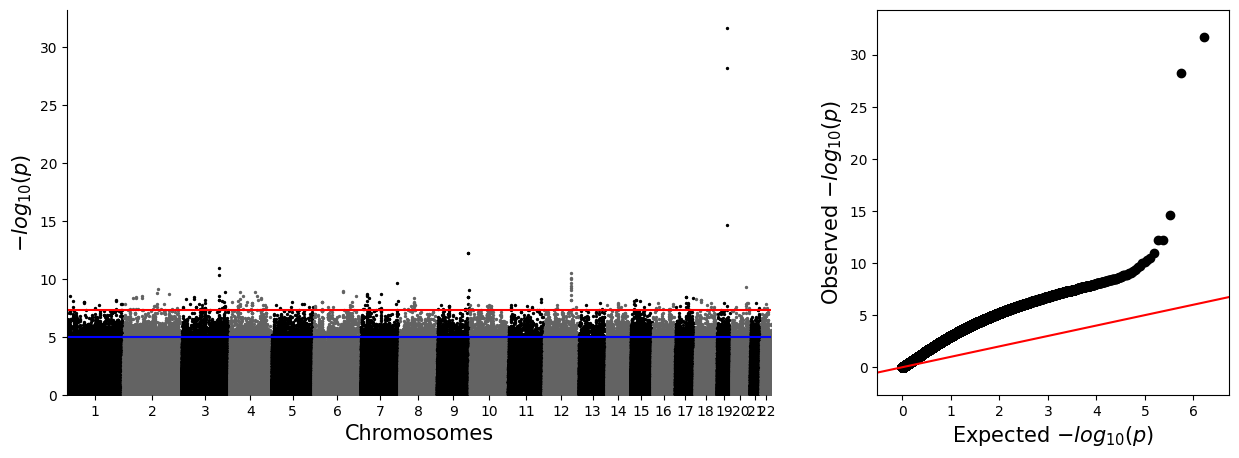

In [44]:
# Reference output from plink without covariates

data = pd.read_csv("gwas_large.assoc.linear", sep='\s+')
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]})
fig.set_size_inches((15, 5))
qqman.manhattan(data, ax=ax0)
qqman.qqplot(data, ax=ax1)

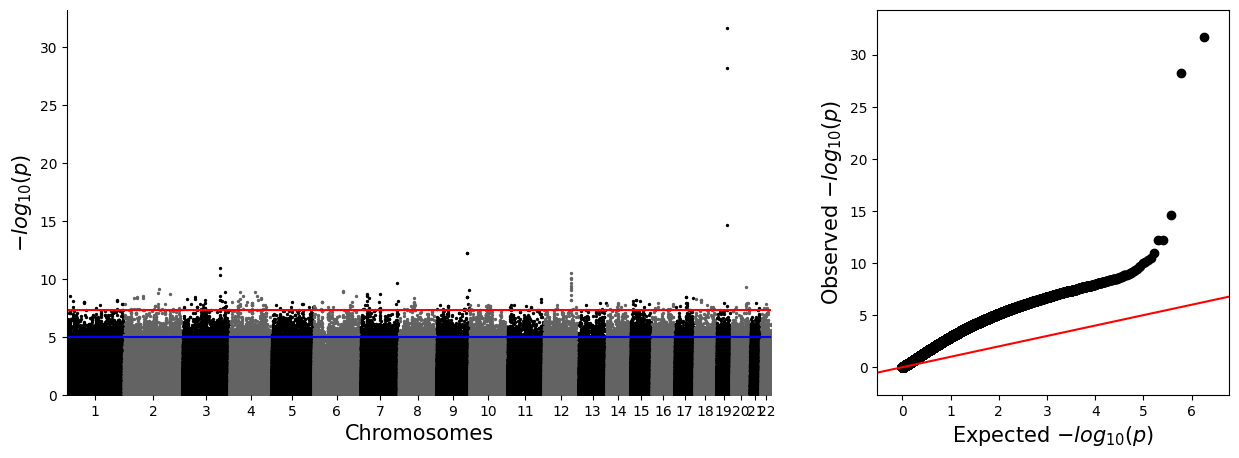

In [47]:
# Output from Simple GWAS Utility without covariates

data = pd.read_csv("gwas_large_out", sep='\s+')
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]})
fig.set_size_inches((15, 5))
qqman.manhattan(data, ax=ax0)
qqman.qqplot(data, ax=ax1)

## Output with covariates

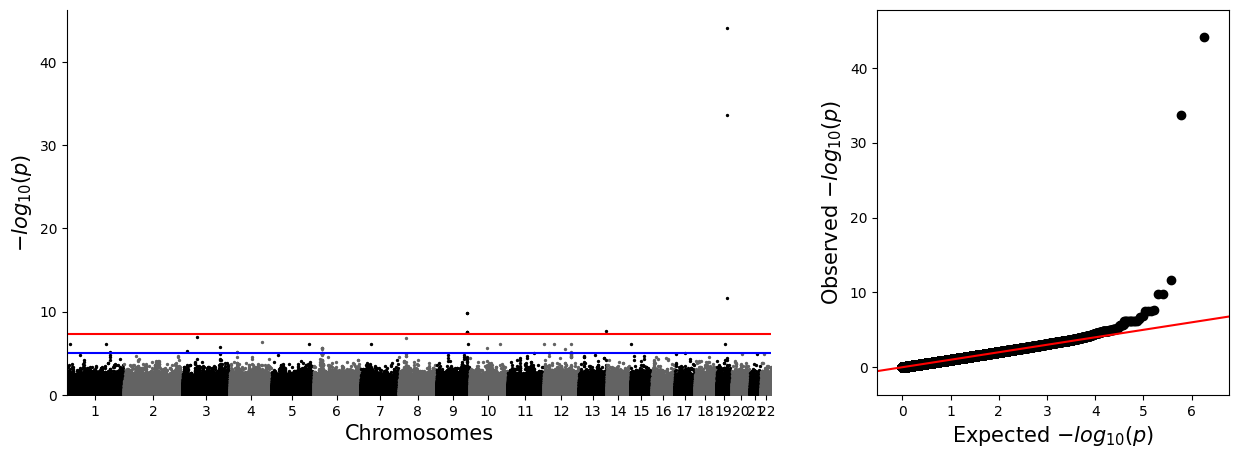

In [46]:
# Reference output from plink WITH covariates

data = pd.read_csv("gwas_large_covar.assoc.linear", sep='\s+')
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]})
fig.set_size_inches((15, 5))
qqman.manhattan(data, ax=ax0)
qqman.qqplot(data, ax=ax1)

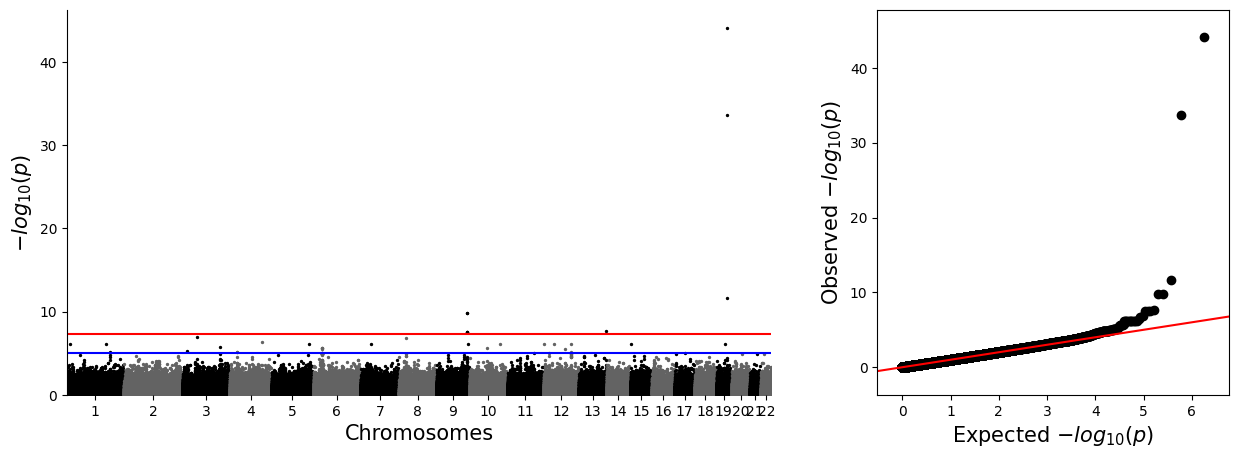

In [6]:
# Output from Simple GWAS Utility WITH covariates

data = pd.read_csv("gwas_large_covar_out", sep='\s+')
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]})
fig.set_size_inches((15, 5))
qqman.manhattan(data, ax=ax0)
qqman.qqplot(data, ax=ax1)

The data used in the plots above were produced with the following commands
- `gwas.eigenvec` file

```
plink --vcf ~/public/ps3/ps3_gwas.vcf.gz --double-id --pca 3 --out gwas
```

- plink without covariates

> Taken from `~/public/ps3/ps3_gwas.assoc.linear`

- Simple GWAS Utility without covariates

```
python gwas.py \
    --vcf ~/public/ps3/ps3_gwas.vcf.gz \
    --pheno data/gwas.phen \
    --maf 0.05 \
    --out gwas_large_out
```

- plink with covariates

```
plink --vcf ~/public/ps3/ps3_gwas.vcf.gz \
    --pheno data/gwas.phen \
    --covar data/gwas.eigenvec \
    --linear hide-covar \
    --allow-no-sex \
    --out gwas_covar
```

- Simple GWAS Utility with covariates

```
python gwas.py \
    --vcf ~/public/ps3/ps3_gwas.vcf.gz \
    --pheno data/gwas.phen \
    --covar data/gwas.eigenvec \
    --out gwas_large_covar_out
```

### Compare Output

In [11]:
# Output from plink without covariates

df = pd.read_csv("gwas_large.assoc.linear", sep="\s+")
df = df.drop(columns=["A1", "TEST", "NMISS"])
df.head()

,CHR,SNP,BP,BETA,STAT,P
0,10,rs11252127,98087,-0.20430,-1.6060,0.1097
1,10,rs7909677,111955,0.19160,0.9108,0.3635
2,10,rs11591988,126070,-0.14700,-0.6690,0.5043
3,10,rs12768206,134767,-0.05717,-0.6032,0.5471
4,10,rs10904561,135656,-0.17850,-1.4710,0.1429


In [19]:
# Output from Simple GWAS Utility without covariates

df2 = pd.read_csv("gwas_large_out", sep="\t")
df2.head()

,CHR,SNP,BP,BETA,STAT,P
0,10,rs11252127,98087,-0.204280,-1.606358,0.109734
1,10,rs7909677,111955,0.191564,0.910799,0.363471
2,10,rs11591988,126070,-0.146990,-0.668975,0.504264
3,10,rs12768206,134767,-0.057168,-0.603186,0.547052
4,10,rs10904561,135656,-0.178488,-1.470544,0.142948


In [10]:
# Output from plink with covariates

df3 = pd.read_csv("gwas_large_covar.assoc.linear", sep="\s+")
df3 = df3.drop(columns=["A1", "TEST", "NMISS"])
df3.head()

,CHR,SNP,BP,BETA,STAT,P
0,10,rs11252127,98087,-0.02279,-0.1785,0.8585
1,10,rs7909677,111955,0.19680,0.9760,0.3302
2,10,rs11591988,126070,0.22420,1.0130,0.3125
3,10,rs12768206,134767,0.02811,0.3078,0.7585
4,10,rs10904561,135656,0.05828,0.4637,0.6434


In [23]:
# Output from Simple GWAS Utility with covariates

df4 = pd.read_csv("gwas_large_covar_out", sep="\t")
df4.head()

,CHR,SNP,BP,BETA,STAT,P
0,10,rs11252127,98087,-0.022792,-0.178506,0.858504
1,10,rs7909677,111955,0.196770,0.976040,0.330212
2,10,rs11591988,126070,0.224179,1.012504,0.312508
3,10,rs12768206,134767,0.028114,0.307817,0.758539
4,10,rs10904561,135656,0.058278,0.463676,0.643379


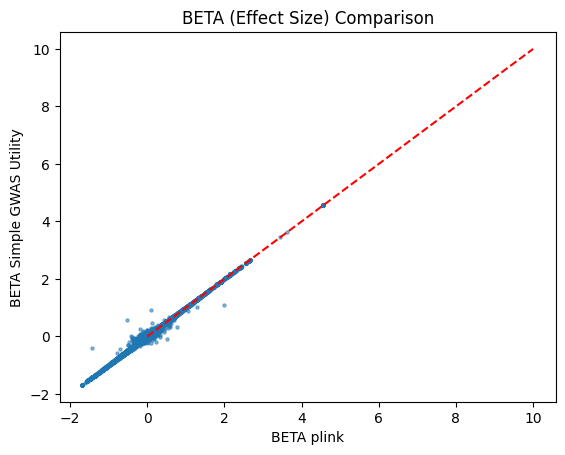

In [40]:
plt.scatter(df3["BETA"], df4["BETA"], s=5, alpha=0.5)
plt.xlabel("BETA plink")
plt.ylabel("BETA Simple GWAS Utility")
plt.plot([0,10],[0,10],'r--')
plt.title("BETA (Effect Size) Comparison")
plt.show()

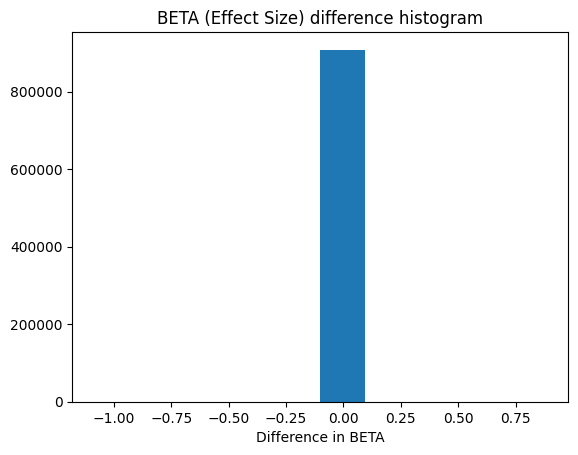

In [43]:
diff = df3["BETA"] - df4["BETA"]
plt.hist(diff, bins=10)
plt.xlabel("Difference in BETA")
plt.title("BETA (Effect Size) difference histogram")
plt.show()

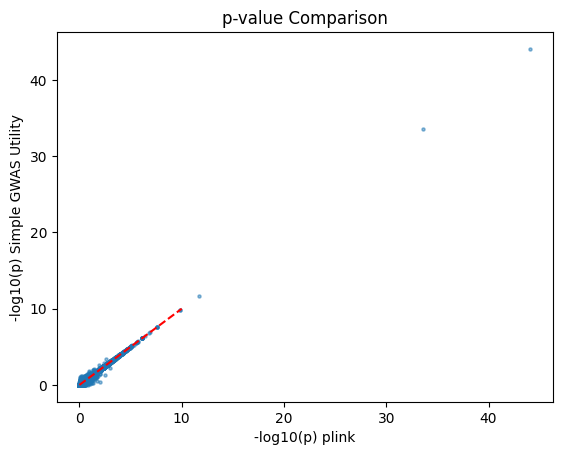

In [28]:
plt.scatter(-np.log10(df3["P"]), -np.log10(df4["P"]), s=5, alpha=0.5)
plt.xlabel("-log10(p) plink")
plt.ylabel("-log10(p) Simple GWAS Utility")
plt.plot([0,10],[0,10],'r--')
plt.title("p-value Comparison")
plt.show()

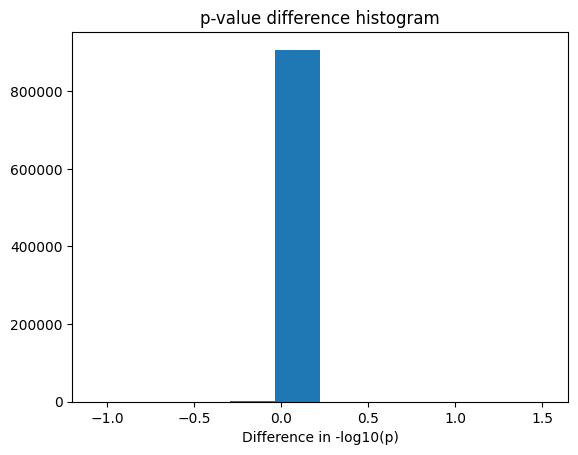

In [37]:
diff = -np.log10(df3["P"]) - (-np.log10(df4["P"]))
plt.hist(diff, bins=10)
plt.xlabel("Difference in -log10(p)")
plt.title("p-value difference histogram")
plt.show()

### The logs for running gwas on plink with covariates
> There is a discrepancy between the output name and the name of the file used in the plot above.
> The file was simply renamed after being generated to conform to a more consistent naming convention.

```
Start time: Sun Mar  8 08:13:39 2026

Random number seed: 1772957619
515764 MB RAM detected; reserving 257882 MB for main workspace.
--vcf: gwas_covar-temporary.bed + gwas_covar-temporary.bim +
gwas_covar-temporary.fam written.
917845 variants loaded from .bim file.
207 people (0 males, 0 females, 207 ambiguous) loaded from .fam.
Ambiguous sex IDs written to gwas_covar.nosex .
207 phenotype values present after --pheno.
Using 1 thread (no multithreaded calculations invoked).
--covar: 3 covariates loaded.
Before main variant filters, 207 founders and 0 nonfounders present.
Calculating allele frequencies... done.
Total genotyping rate is 0.999834.
917845 variants and 207 people pass filters and QC.
Phenotype data is quantitative.
Writing linear model association results to gwas_covar.assoc.linear ... done.

End time: Sun Mar  8 12:32:02 2026
```

### The logs for running gwas on Simple GWAS Utility with covariates

```
Loading genotypes
917845it [01:23, 11012.54it/s]
Done
  0%|                                                                                                    | 0/917074 [00:00<?, ?it/s]/home/y2chi/simple-gwas-utility/gwas.py:23: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  coeffs, residuals, rank, _ = np.linalg.lstsq(X, y)
100%|█████████████████████████████████████████████████████████████████████████████████████| 917074/917074 [04:19<00:00, 3537.07it/s]
```

The above logs were produced by running the commands on a datahub 4-cpu 16gb-ram instance. According to the logs, plink took roughly 4 hours and 20 minutes to complete, while Simple GWAS Utility took 5 minutes and 42 seconds. It is peculiar that plink took this long to complete the calculations as it is supposed to be highly optimized with parallel computing. As such, there is likely an issue with the environment, whether it be at the OS or the hardware level. Unfortunately, this means the computation efficiency could not be compared in a fair manner.

### Note

The effect size and p values produced by Simple GWAS Utility were nearly identical to those from plink. However, the utility seems to have omitted an extra 586 snps from the output when supplied the option `--maf 0.05`.